In [82]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

import os
print("Current working directory:", os.getcwd())

Current working directory: /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model


# Verify Model to T-Shirt CFE

# Trained dCFE Model (dynamic spinup + prediction)
To do this, there are several steps. First, we'll need to examine parameters from a trained LSTM by
1. Grab data needed for LSTM, normalize them
2. Grab wights from trained LSTM model, use them to predict params
3. Graph params over time 

Second, verify "manually" computed outputs via CFE match NH computed outputs, & compare to "calibrated params"

4. Grab evaluated results from trained NH-dCFE model
5. Use calibrated fixed parameters to predict for same time period, and
6. Use time-varying parameters from before to predict for the same time period, compare runoff to both previous realizations (4, 5).

Thirdly, examine internal states and other quantity of interest.

7. Graph internal states overtime, make sure to have correct units

## Parameters from LSTM

In [83]:
# Define the path to the testData folder & grab data
test_data_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/testData")
inputLSTMFile = pd.read_csv('02177000_lstm_input.csv')

# Normalize the lstm input data
input_lstm = torch.zeros(2, len(inputLSTMFile), len(inputLSTMFile.columns) - 1) # [batch_size = 2, time_steps, forcing]
# ^^^wierd batch size to minimum amout of code edits needed. Info will only be stored in [0,:,:]
input_lstm[0, :, 0] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_nldas'].values - np.mean(inputLSTMFile['PRCP(mm/day)_nldas'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_nldas'].values))
input_lstm[0, :, 1] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_maurer'].values - np.mean(inputLSTMFile['PRCP(mm/day)_maurer'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_maurer'].values))
input_lstm[0, :, 2] = torch.Tensor((inputLSTMFile['prcp(mm/day)_daymet'].values - np.mean(inputLSTMFile['prcp(mm/day)_daymet'].values))/
                                   np.std(inputLSTMFile['prcp(mm/day)_daymet'].values))
input_lstm[0, :, 3] = torch.Tensor((inputLSTMFile['srad(W/m2)_daymet'].values - np.mean(inputLSTMFile['srad(W/m2)_daymet'].values))/
                                   np.std(inputLSTMFile['srad(W/m2)_daymet'].values))
input_lstm[0, :, 4] = torch.Tensor((inputLSTMFile['tmax(C)_daymet'].values - np.mean(inputLSTMFile['tmax(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmax(C)_daymet'].values))
input_lstm[0, :, 5] = torch.Tensor((inputLSTMFile['tmin(C)_daymet'].values - np.mean(inputLSTMFile['tmin(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmin(C)_daymet'].values))
input_lstm[0, :, 6] = torch.Tensor((inputLSTMFile['vp(Pa)_daymet'].values - np.mean(inputLSTMFile['vp(Pa)_daymet'].values))/
                                   np.std(inputLSTMFile['vp(Pa)_daymet'].values))

Also define function to grab model weights and predict the params.

In [ ]:
# Defining a function that grabs weights & makes prediction
def load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size):
    """
    Load LSTM weights and make predictions using a function-based approach.
    
    Args:
        input_data (torch.Tensor): Input tensor of shape (batch_size, seq_length, input_size).
        weights_path (str): Path to the .pt file containing model weights.
        input_size (int): Number of input features per time step.
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
        output_size (int): Number of output features.
    
    Returns:
        torch.Tensor: Predictions from the model.
    """
    # Define the LSTM and linear layers
    lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    fc = nn.Linear(hidden_size, output_size)
    
    # Load weights
    state_dict = torch.load(weights_path)
    
    # Map LSTM weights
    lstm_state_dict = {k.replace("lstm.", ""): v for k, v in state_dict.items() if k.startswith("lstm.")}
    lstm.load_state_dict(lstm_state_dict)
    
    # Map fully connected (linear) layer weights
    if "linear.weight" in state_dict and "linear.bias" in state_dict:
        fc_state_dict = {
            "weight": state_dict["linear.weight"],
            "bias": state_dict["linear.bias"]
        }
        fc.load_state_dict(fc_state_dict)
    else:
        raise RuntimeError("Missing keys for linear layer in state_dict. Check the key names.")
    
    # Set evaluation mode
    lstm.eval()
    fc.eval()
    
    # Perform forward pass
    with torch.no_grad():
        lstm_out, _ = lstm(input_data)  # Get output from LSTM
        lstm_pred = fc(lstm_out)  # Pass through the fully connected layer
    
    # Apply sigmoid and scaling to each column
    predictions = torch.zeros_like(lstm_pred)
    predictions[:, :, 0] = torch.sigmoid(lstm_pred[:, :, 0]) * 0.000726 + 0.0 # satdk
    predictions[:, :, 1] = torch.sigmoid(lstm_pred[:, :, 1]) * (0.0018 - 0.0000018) + 0.0000018 # Cgw
    predictions[:, :, 2] = torch.sigmoid(lstm_pred[:, :, 2]) * 21.94 + 0.0 # bb
    predictions[:, :, 3] = torch.sigmoid(lstm_pred[:, :, 3]) * (1.0 - 0.20554) + 0.20554 # smcmax
    predictions[:, :, 4] = torch.sigmoid(lstm_pred[:, :, 4]) * 1.0 + 0.0 # slop
    predictions[:, :, 5] = torch.sigmoid(lstm_pred[:, :, 5]) * (0.25 - 0.01) + 0.01 # max_gw
    predictions[:, :, 6] = torch.sigmoid(lstm_pred[:, :, 6]) * (8.0 - 1.0) + 1.0 # expon
    predictions[:, :, 7] = torch.sigmoid(lstm_pred[:, :, 7]) * 1.0 + 0.0 # K_lf
    predictions[:, :, 8] = torch.sigmoid(lstm_pred[:, :, 8]) * 1.0 + 0.0 # K_nash
    
    return predictions

def calculate_nse(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE) between observed and simulated data.

    Parameters:
    observed (list or numpy array): Observed data values.
    simulated (list or numpy array): Simulated data values.

    Returns:
    float: The NSE value.
    """
    # Convert inputs to numpy arrays
    observed = np.array(observed)
    simulated = np.array(simulated)

    # Ensure the observed and simulated arrays have the same length
    if len(observed) != len(simulated):
        raise ValueError("Observed and simulated data must have the same length.")

    # Calculate the numerator and denominator of the NSE formula
    numerator = np.sum((observed - simulated) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)

    # Avoid division by zero
    if denominator == 0:
        raise ValueError("The denominator of the NSE calculation is zero.")

    # Compute NSE
    nse = 1 - (numerator / denominator)

    return nse

In [81]:
# Grab config file that trained this model
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/basin_dCFEwPETDaily.yml')
config = Config(config_path, dev_mode=True)

# Grab results from evaluated model
run_dir = Path("runs/TestdCFEDaily_run02177000_GoodDynamic5epoch_1102_210529")
with open(run_dir / "test" / "model_epoch005" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)

input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 9 # satdk, cgw, and 7 other outputs
weights_path = run_dir/"model_epoch005.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
predictions = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)


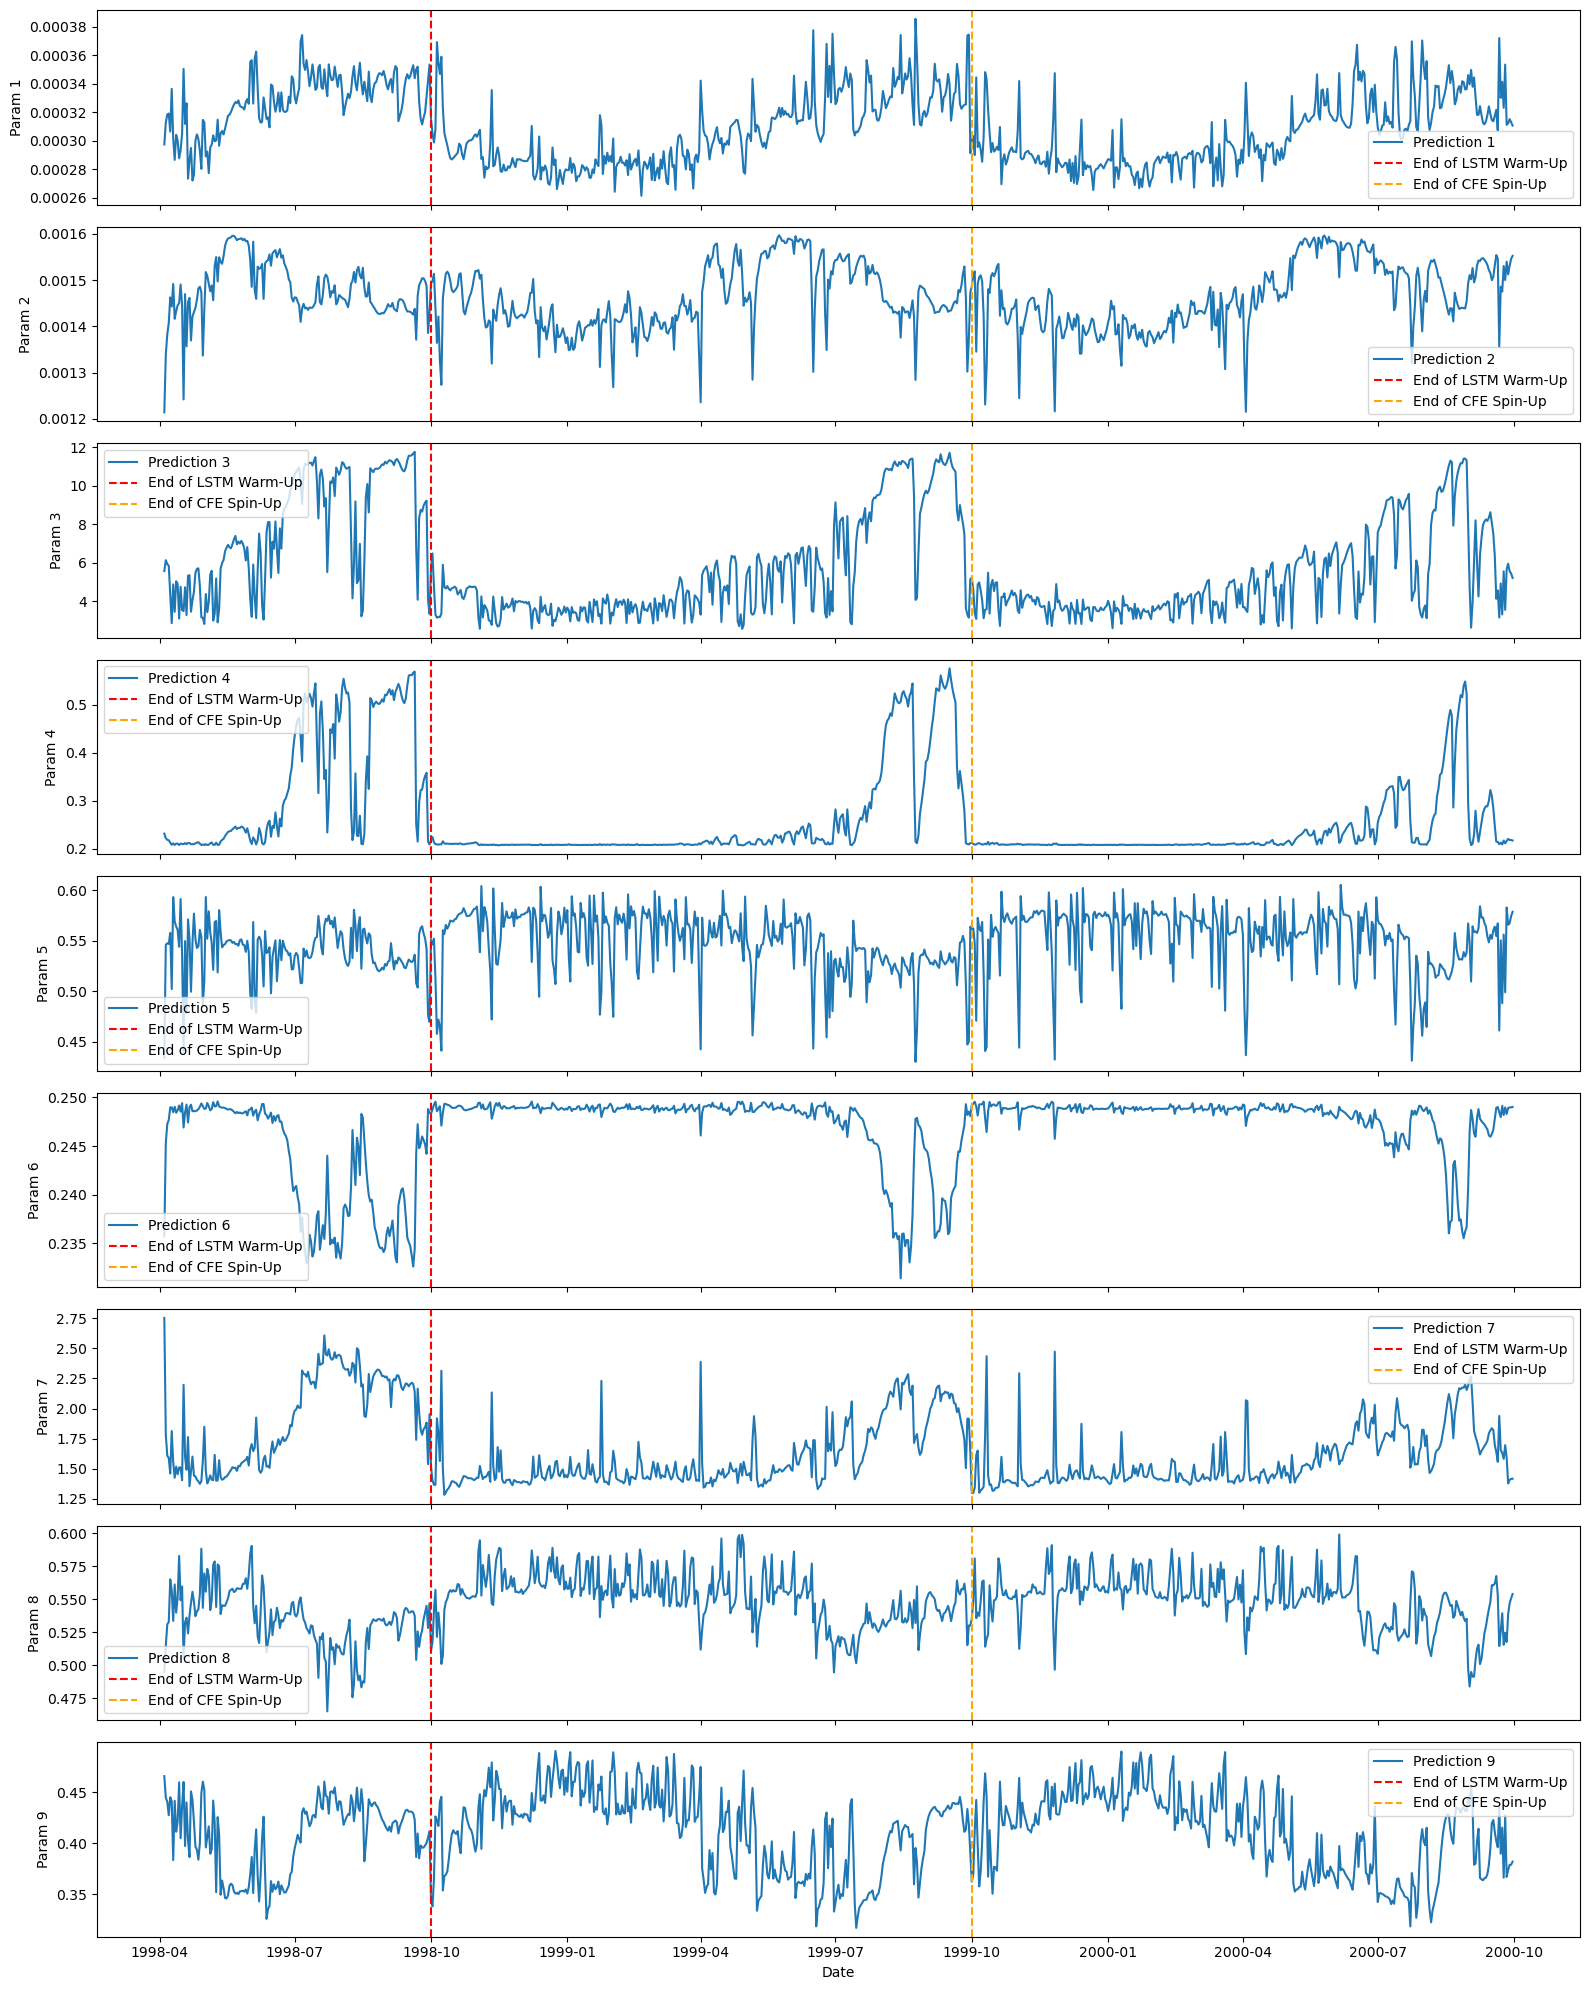

In [89]:
# Extract dates from input_lstm
dates_param = pd.date_range(start='1998-04-04', periods=input_lstm.shape[1], freq='D')

# Plot all columns of the predictions against the dates
fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(16, 20), sharex=True)
for i in range(9):
    axes[i].plot(dates_param, predictions[0, :, i].numpy(), label=f'Prediction {i+1}')
    axes[i].axvline(pd.Timestamp('1998-10-01'), color='red', linestyle='--', label='End of LSTM Warm-Up') 
    axes[i].axvline(pd.Timestamp('1999-10-01'), color='orange', linestyle='--', label='End of CFE Spin-Up') 
    axes[i].set_ylabel(f'Param {i+1}')
    axes[i].legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


In [ ]:
results['02177000']['1D']['NSE']

# Extract a date slice of observations and simulations
Result_xr = results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar = Result_xr.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values = Result_xr.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr = Result_xr.assign_coords(datetime=("time_step", datetime_values))

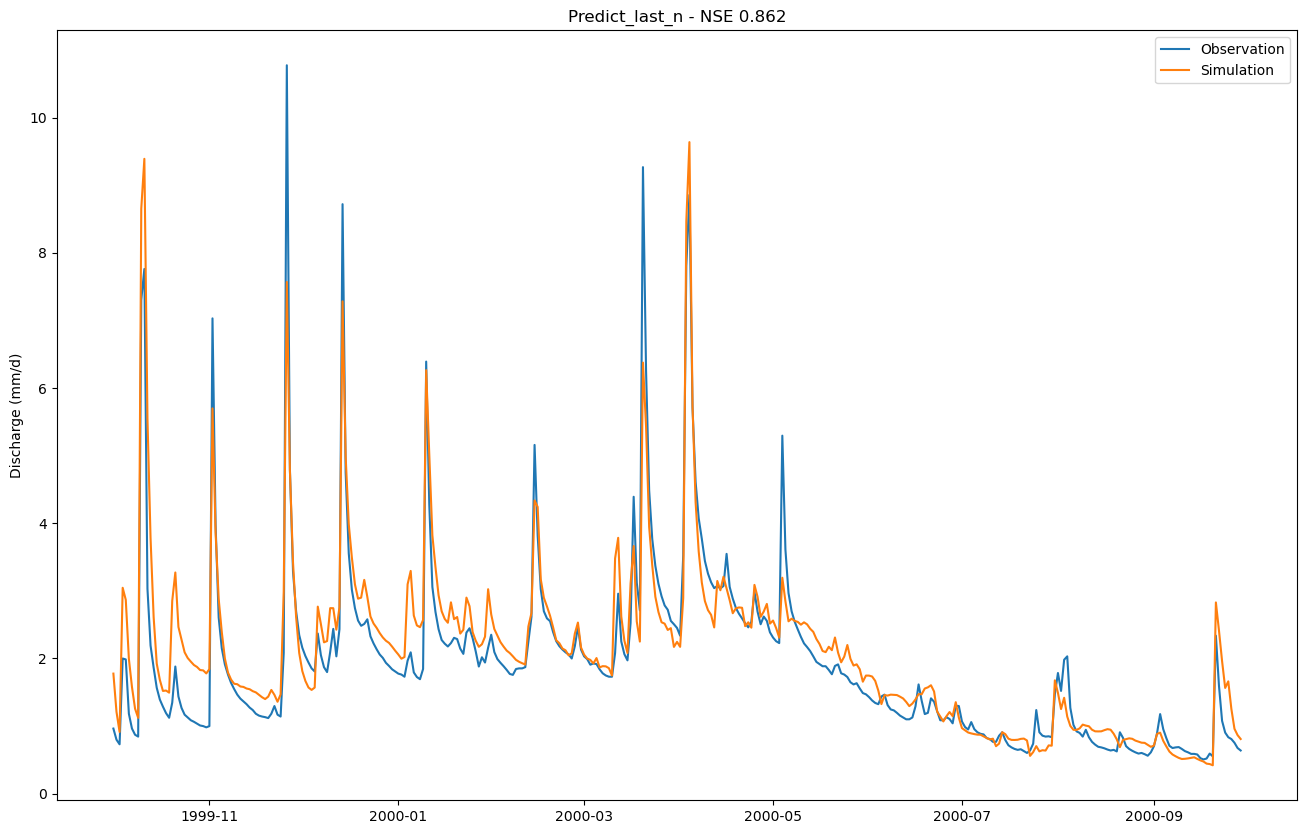

In [ ]:
# Extract observations and simulations
qobs = Result_xr['QObs(mm/d)_obs']
qsim = Result_xr['QObs(mm/d)_sim']

result_NSE = calculate_nse(qobs[0,:], qsim[0,:])
# Plot observations and simulations
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(Result_xr['datetime'], qobs[0,:], label="Observation")
ax.plot(Result_xr['datetime'], qsim[0,:], label="Simulation")
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Predict_last_n - NSE {result_NSE:.3f}")
_ = ax.legend()

In [35]:
from neuralhydrology.modelzoo.dcfeDaily import dCFE
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.dCFE_utils import get_dcfe_params

config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/basin_dCFEwPETDaily.yml')
config = Config(config_path, dev_mode=True)

soil_params, basinCharacteristics = get_dcfe_params(config, 'mps')

910